In [130]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [92]:
data = pd.read_csv("../data/raw/Airline_Delay_Cause.csv")
data = data.dropna(subset = ['arr_flights', 'arr_del15']) # Удаляем пропуски в данных столбцах, потому что их количество черезмерно мало

In [93]:
display(data.shape, data.isna().sum())

(171223, 21)

year                   0
month                  0
carrier                0
carrier_name           0
airport                0
airport_name           0
arr_flights            0
arr_del15              0
carrier_ct             0
weather_ct             0
nas_ct                 0
security_ct            0
late_aircraft_ct       0
arr_cancelled          0
arr_diverted           0
arr_delay              0
carrier_delay          0
weather_delay          0
nas_delay              0
security_delay         0
late_aircraft_delay    0
dtype: int64

In [94]:
# Количество пропусков
data.isna().sum()

year                   0
month                  0
carrier                0
carrier_name           0
airport                0
airport_name           0
arr_flights            0
arr_del15              0
carrier_ct             0
weather_ct             0
nas_ct                 0
security_ct            0
late_aircraft_ct       0
arr_cancelled          0
arr_diverted           0
arr_delay              0
carrier_delay          0
weather_delay          0
nas_delay              0
security_delay         0
late_aircraft_delay    0
dtype: int64

In [95]:
# Количество дубликатов
data.duplicated().sum()

np.int64(0)

In [96]:
# Типы данных
data.dtypes

year                     int64
month                    int64
carrier                 object
carrier_name            object
airport                 object
airport_name            object
arr_flights            float64
arr_del15              float64
carrier_ct             float64
weather_ct             float64
nas_ct                 float64
security_ct            float64
late_aircraft_ct       float64
arr_cancelled          float64
arr_diverted           float64
arr_delay              float64
carrier_delay          float64
weather_delay          float64
nas_delay              float64
security_delay         float64
late_aircraft_delay    float64
dtype: object

In [97]:
x = (data['arr_delay'] == 0).sum().astype(int)
y = (data['arr_delay'] != 0).sum().astype(int)
display(x, y)

np.int64(6585)

np.int64(164638)

In [98]:
display(data['arr_del15'].min(), data['arr_del15'].max())

np.float64(0.0)

np.float64(4176.0)

In [99]:
(data['arr_flights'] == 0).sum()

np.int64(0)

In [100]:
bad_month = ((data['arr_del15'] / (data['arr_flights'])) * 100) > 20.0

#example = (data['arr_del15'] / (data['arr_flights'])) * 100
#display(example.quantile(0.25), example.median(), example.quantile(0.75))

In [101]:
display((bad_month == False).sum(), (bad_month == True).sum(), ((bad_month == False).sum() / len(bad_month)), ((bad_month == True).sum() / len(bad_month)))

np.int64(106180)

np.int64(65043)

np.float64(0.6201269689235676)

np.float64(0.3798730310764325)

<Axes: >

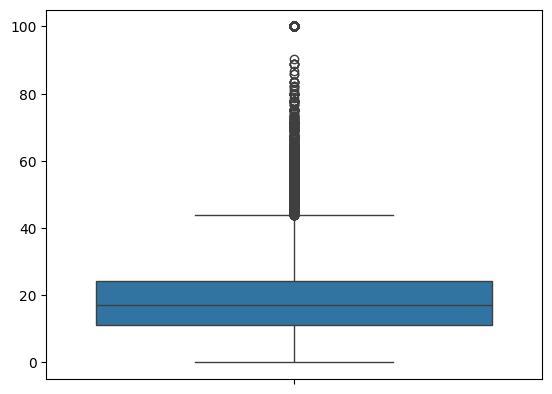

In [102]:
sns.boxplot((data['arr_del15'] / (data['arr_flights'])) * 100)

In [103]:
data['arr_del15'].isna().sum() / len(data['arr_del15'])

np.float64(0.0)

# Analyze of carriers

In [105]:
delay_rate = data['arr_del15'] / data['arr_flights'] * 100

In [106]:
print(f"Min: {delay_rate.min()}, Median: {delay_rate.median()}, Max: {delay_rate.max()}, 25 quart: {delay_rate.quantile(0.25)}, 75 quart: {delay_rate.quantile(0.75)}, 90 quart: {delay_rate.quantile(0.9)} ")

Min: 0.0, Median: 17.073170731707318, Max: 100.0, 25 quart: 10.989010989010989, 75 quart: 24.152808200242433, 90 quart: 31.896551724137932 


<Axes: ylabel='Count'>

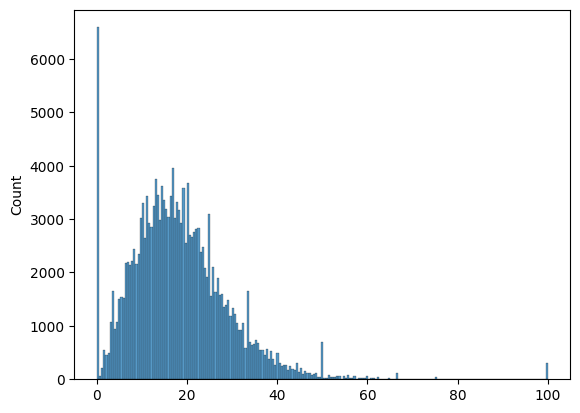

In [109]:
sns.histplot(delay_rate)

Распределение у delay_rate не нормальное,есть пик в нуле и хвост справа

In [129]:
## Авиакомпании с проблемными месяцами
data['bad_month'] = bad_month
print(data['carrier_name'].value_counts())
print('----------------')
print(data.groupby('carrier_name').size().sort_values())
print('----------------')
print(data.groupby('carrier_name')['bad_month'].mean())

carrier_name
SkyWest Airlines Inc.           25521
Delta Air Lines Inc.            16669
Envoy Air                       11859
American Airlines Inc.          11809
United Air Lines Inc.           11236
Southwest Airlines Co.          11109
ExpressJet Airlines Inc.        10114
Frontier Airlines Inc.           9088
Alaska Airlines Inc.             8365
Allegiant Air                    8217
Endeavor Air Inc.                7559
JetBlue Airways                  7547
Mesa Airlines Inc.               6341
PSA Airlines Inc.                6183
Republic Airline                 5702
Spirit Air Lines                 4689
Hawaiian Airlines Inc.           2156
US Airways Inc.                  1708
ExpressJet Airlines LLC          1419
Horizon Air                      1157
Virgin America                   1132
American Eagle Airlines Inc.     1044
AirTran Airways Corporation       599
Name: count, dtype: int64
----------------
carrier_name
AirTran Airways Corporation       599
American Eagle Airl

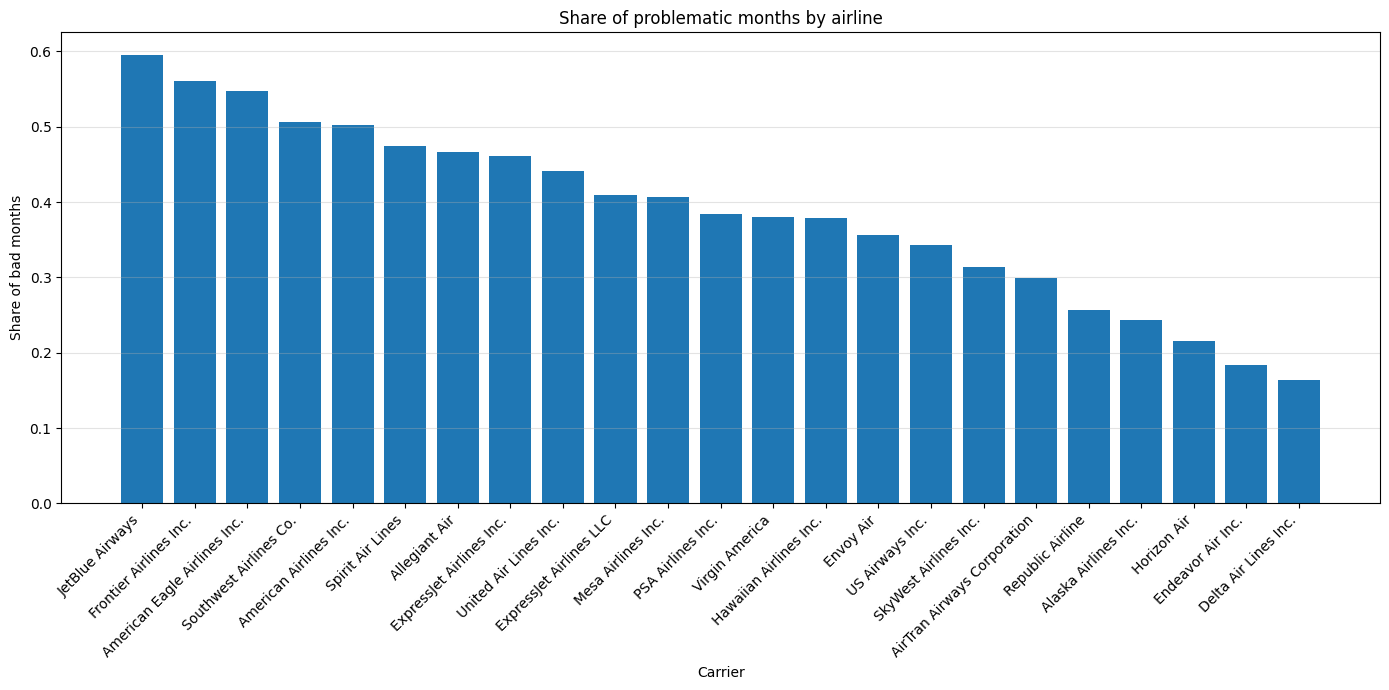

In [140]:
carrier_bad_rate = (data.groupby('carrier_name')['bad_month'].mean().sort_values(ascending = False))
plt.figure(figsize = (14, 7))

plt.bar(
    carrier_bad_rate.index,
    carrier_bad_rate.values
)

plt.xticks(rotation = 45, ha = 'right')
plt.ylabel('Share of bad months')
plt.xlabel('Carrier')

plt.title('Share of problematic months by airline')

plt.grid(axis = 'y', alpha = 0.35)

plt.tight_layout()
plt.show()

JetBlue Airways, Frontier Airlines и American Eagle Airlines **имеют самую высокую долю проблемных месяцев.**
Delta Air Lines, Endeavor Air и Horizon Air — **самую низкую.**

## Анализ аэропортов

In [146]:
data.groupby('airport_name').value_counts()

airport_name                            year  month  carrier  carrier_name           airport  arr_flights  arr_del15  carrier_ct  weather_ct  nas_ct  security_ct  late_aircraft_ct  arr_cancelled  arr_diverted  arr_delay  carrier_delay  weather_delay  nas_delay  security_delay  late_aircraft_delay  bad_month
Aberdeen, SD: Aberdeen Regional         2013  8      OO       SkyWest Airlines Inc.  ABR      62.0         5.0        3.74        0.00        0.28    0.0          0.98              0.0            0.0           256.0      229.0          0.0            8.0        0.0             19.0                 False        1
                                              9      OO       SkyWest Airlines Inc.  ABR      60.0         3.0        1.00        0.83        1.18    0.0          0.00              0.0            0.0           128.0      66.0           33.0           29.0       0.0             0.0                  False        1
                                              10     OO       S

In [153]:
data.groupby('airport_name').value_counts()

airport_name                            year  month  carrier  carrier_name           airport  arr_flights  arr_del15  carrier_ct  weather_ct  nas_ct  security_ct  late_aircraft_ct  arr_cancelled  arr_diverted  arr_delay  carrier_delay  weather_delay  nas_delay  security_delay  late_aircraft_delay  bad_month
Aberdeen, SD: Aberdeen Regional         2013  8      OO       SkyWest Airlines Inc.  ABR      62.0         5.0        3.74        0.00        0.28    0.0          0.98              0.0            0.0           256.0      229.0          0.0            8.0        0.0             19.0                 False        1
                                              9      OO       SkyWest Airlines Inc.  ABR      60.0         3.0        1.00        0.83        1.18    0.0          0.00              0.0            0.0           128.0      66.0           33.0           29.0       0.0             0.0                  False        1
                                              10     OO       S

In [156]:
data.groupby('airport_name').size().sort_values()

airport_name
Youngstown/Warren, OH: Youngstown-Warren Regional                1
Mobile, AL: Mobile International                                 1
Fort Collins/Loveland, CO: Northern Colorado Regional            1
Williamsport, PA: Williamsport Regional                          3
Inyokern, CA: Inyokern Airport                                   4
                                                              ... 
Atlanta, GA: Hartsfield-Jackson Atlanta International         1510
New Orleans, LA: Louis Armstrong New Orleans International    1512
Raleigh/Durham, NC: Raleigh-Durham International              1515
Austin, TX: Austin - Bergstrom International                  1526
Detroit, MI: Detroit Metro Wayne County                       1535
Length: 415, dtype: int64

In [161]:
print(data.groupby('airport_name')['bad_month'].mean())

airport_name
Aberdeen, SD: Aberdeen Regional                      0.099174
Abilene, TX: Abilene Regional                        0.272000
Adak Island, AK: Adak                                0.347107
Aguadilla, PR: Rafael Hernandez                      0.752294
Akron, OH: Akron-Canton Regional                     0.438000
                                                       ...   
Wrangell, AK: Wrangell Airport                       0.330579
Yakima, WA: Yakima Air Terminal/McAllister Field     0.208333
Yakutat, AK: Yakutat Airport                         0.140496
Youngstown/Warren, OH: Youngstown-Warren Regional    1.000000
Yuma, AZ: Yuma MCAS/Yuma International               0.151515
Name: bad_month, Length: 415, dtype: float64


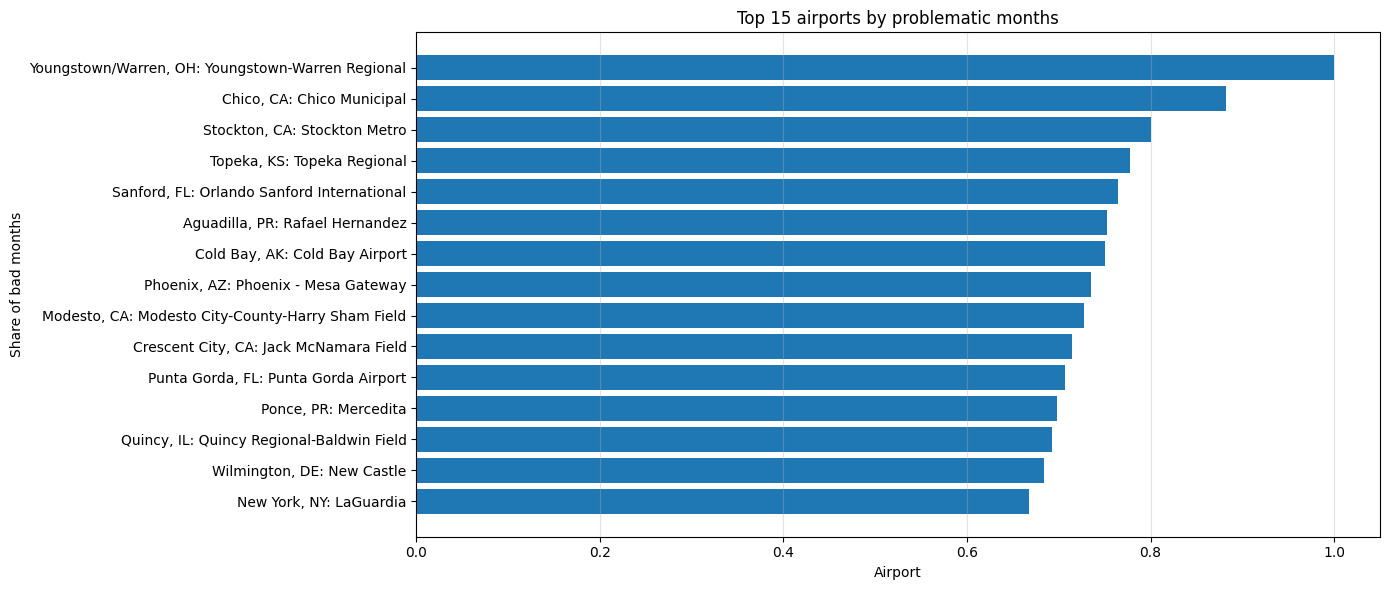

In [177]:
airport_bad_rate = (data.groupby('airport_name')['bad_month'].mean().sort_values(ascending = False).head(15))
plt.figure(figsize = (14, 6))

plt.barh(
    airport_bad_rate.index[::-1],
    airport_bad_rate.values[::-1]
)

plt.ylabel('Share of bad months')
plt.xlabel('Airport')
plt.title('Top 15 airports by problematic months')

plt.grid(axis = 'x', alpha = 0.35)

plt.tight_layout()
plt.show()

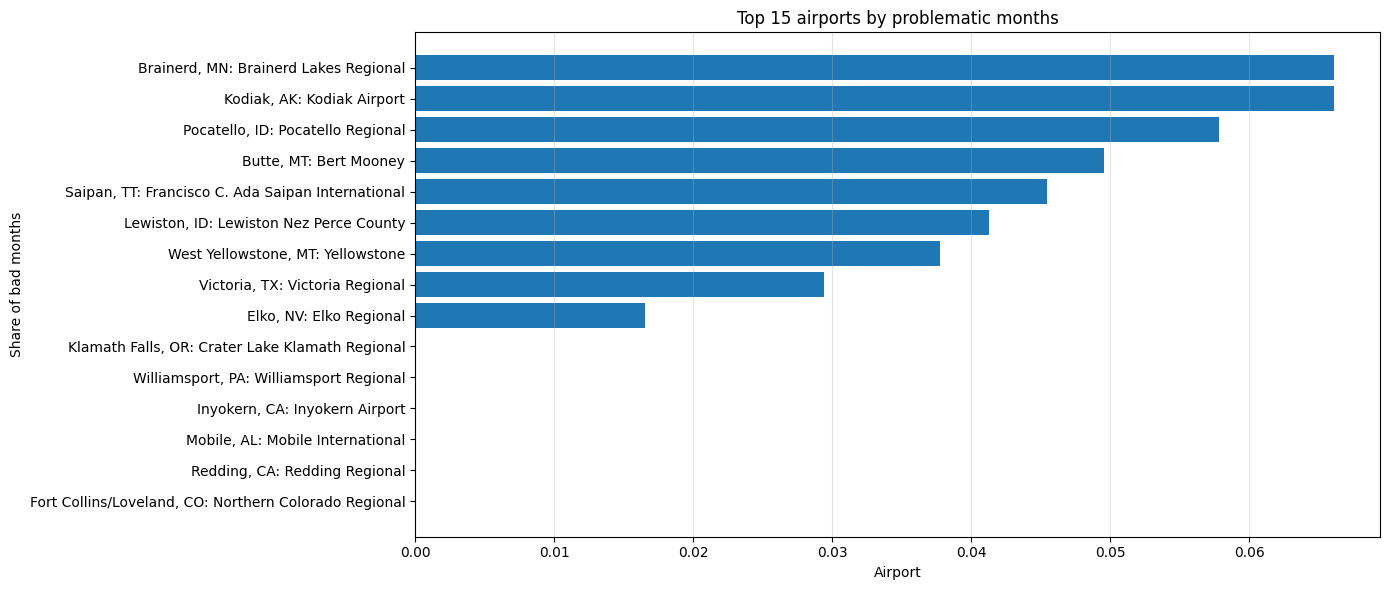

In [178]:
airport_bad_rate = (data.groupby('airport_name')['bad_month'].mean().sort_values(ascending = False).tail(15))
plt.figure(figsize = (14, 6))

plt.barh(
    airport_bad_rate.index[::-1],
    airport_bad_rate.values[::-1]
)

plt.ylabel('Share of bad months')
plt.xlabel('Airport')
plt.title('Top 15 airports by non problematic months')

plt.grid(axis = 'x', alpha = 0.35)

plt.tight_layout()
plt.show()

## Доля проблем по месяцам

In [186]:
month_bad_rate = (data.groupby('month')['bad_month'].mean().sort_values(ascending = False))
month_bad_rate

month
6     0.551220
7     0.534716
12    0.500742
8     0.468084
2     0.409866
1     0.406250
5     0.340288
3     0.319565
4     0.303420
11    0.257751
10    0.248906
9     0.201465
Name: bad_month, dtype: float64

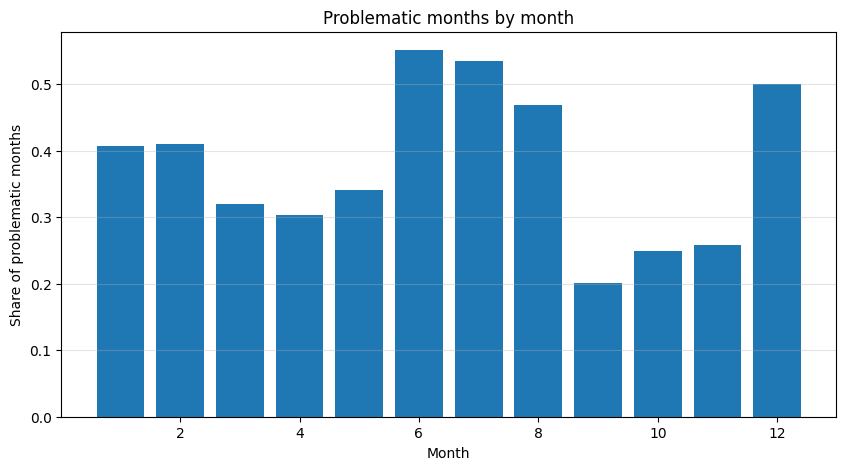

In [187]:
plt.figure(figsize=(10, 5))

plt.bar(
    month_bad_rate.index,
    month_bad_rate.values
)

plt.xlabel('Month')
plt.ylabel('Share of problematic months')
plt.title('Problematic months by month')

plt.grid(axis='y', alpha=0.35)

plt.show()

## Анализ по годам

In [189]:
data.groupby('year')['bad_month'].mean()

year
2013    0.383609
2014    0.533854
2015    0.394139
2016    0.307913
2017    0.360633
2018    0.418561
2019    0.426291
2020    0.085704
2021    0.316524
2022    0.466083
2023    0.540105
Name: bad_month, dtype: float64

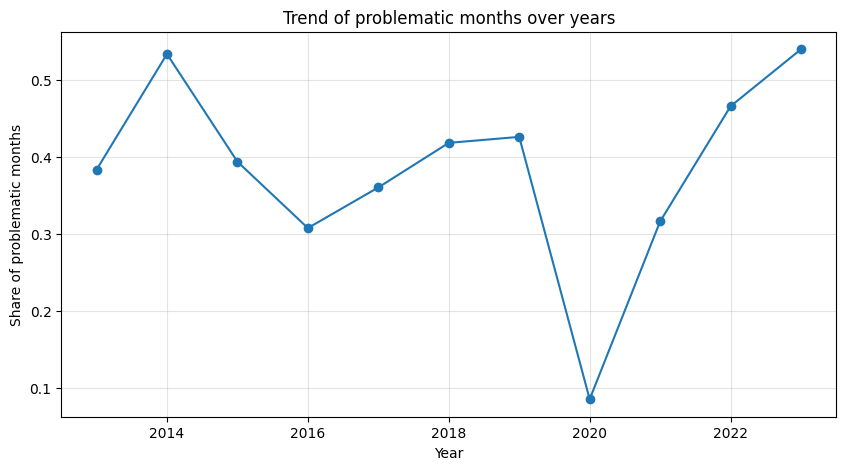

In [197]:
year_bad_rate = (data.groupby('year')['bad_month'].mean())
plt.figure(figsize=(10, 5))

plt.plot(
    year_bad_rate.index,
    year_bad_rate.values,
    marker='o'
)

plt.xlabel('Year')
plt.ylabel('Share of problematic months')
plt.title('Trend of problematic months over years')

plt.grid(alpha=0.35)

plt.show()

## Анализ нагрузки аэропорта

In [198]:
data['arr_flights'].describe()

count    171223.000000
mean        362.946427
std         993.408638
min           1.000000
25%          50.000000
50%         101.000000
75%         250.000000
max       21977.000000
Name: arr_flights, dtype: float64

Теперь посмотрим как влияет загруженность на вероятность проблемного месяца

In [199]:
data['flight_volume'] = pd.qcut(data['arr_flights'], q = 5, labels = ['Very low', 'low', 'Medium', 'High', 'Very High'])
data.groupby('flight_volume')['bad_month'].mean()

C:\Users\anime\AppData\Local\Temp\ipykernel_8368\1949969724.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('flight_volume')['bad_month'].mean()


flight_volume
Very low     0.353498
low          0.354295
Medium       0.371875
High         0.401762
Very High    0.418170
Name: bad_month, dtype: float64

### Причины задержек

In [202]:
delays = ['carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct']
print(data[delays].mean().sort_values(ascending = False))

print("------------")
data.groupby('bad_month')[delays].mean()

late_aircraft_ct    23.798736
carrier_ct          20.821272
nas_ct              19.404125
weather_ct           2.253015
security_ct          0.157283
dtype: float64
------------


,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct
bad_month,,,,,
False,16.435528,1.772556,13.874949,0.122877,17.022572
True,27.980817,3.037344,28.430276,0.213448,34.860543


### Матрица корреляций

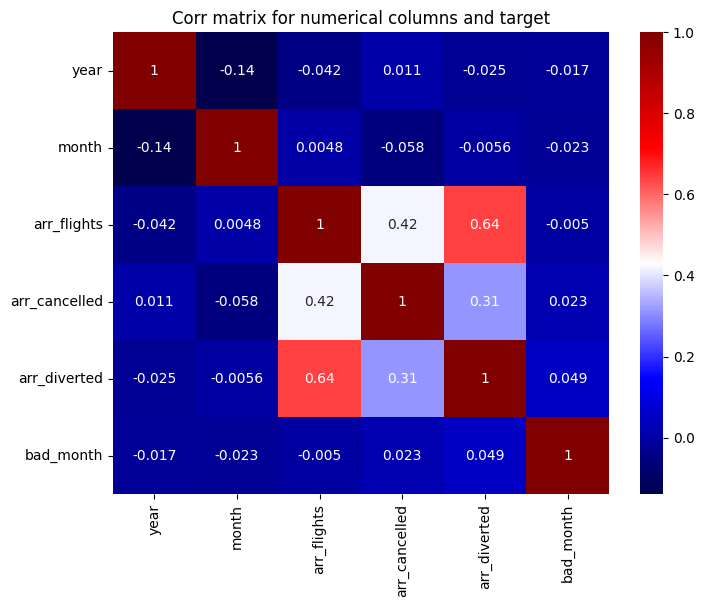

In [213]:
features_for_corr = [
    'year',
    'month',
    'arr_flights',
    'arr_cancelled',
    'arr_diverted',
    'bad_month'
]

plt.figure(figsize = (8, 6))

sns.heatmap(
    data[features_for_corr].corr(),
    annot = True,
    cmap = 'seismic'
)

plt.title('Corr matrix for numerical columns and target')
plt.show()

## Анализ каттегориальных данных

In [214]:
data[['carrier', 'airport']].nunique()

carrier     21
airport    391
dtype: int64

In [215]:
data['airport'].value_counts().describe() # Количество наблюдений по аэропортам

count     391.000000
mean      437.910486
std       444.068278
min         1.000000
25%       111.000000
50%       220.000000
75%       662.000000
max      1535.000000
Name: count, dtype: float64

In [216]:
(data['airport'].value_counts() < 100).sum() # меньше 100 записей на аэропорт

np.int64(84)